In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.decomposition import PCA

In [2]:
# Load dataset
df = pd.read_csv("Zoo.csv")
df.head()

,animal name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,type
0,aardvark,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,antelope,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,bass,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,bear,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,boar,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [3]:
# Dataset info
print("\nDataset Info:")
print(df.info())

# Shape of dataset
print("\nShape of dataset:", df.shape)



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   animal name  101 non-null    object
 1   hair         101 non-null    int64 
 2   feathers     101 non-null    int64 
 3   eggs         101 non-null    int64 
 4   milk         101 non-null    int64 
 5   airborne     101 non-null    int64 
 6   aquatic      101 non-null    int64 
 7   predator     101 non-null    int64 
 8   toothed      101 non-null    int64 
 9   backbone     101 non-null    int64 
 10  breathes     101 non-null    int64 
 11  venomous     101 non-null    int64 
 12  fins         101 non-null    int64 
 13  legs         101 non-null    int64 
 14  tail         101 non-null    int64 
 15  domestic     101 non-null    int64 
 16  catsize      101 non-null    int64 
 17  type         101 non-null    int64 
dtypes: int64(17), object(1)
memory usage: 14.3+ KB
None

Sh

In [4]:
# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
animal name    0
hair           0
feathers       0
eggs           0
milk           0
airborne       0
aquatic        0
predator       0
toothed        0
backbone       0
breathes       0
venomous       0
fins           0
legs           0
tail           0
domestic       0
catsize        0
type           0
dtype: int64


In [6]:
#Checking duplicates
df.duplicated().sum()

np.int64(0)

In [5]:
# Basic statistics
print("\nSummary statistics:")
df.describe().T


Summary statistics:


,count,mean,std,min,25%,50%,75%,max
hair,101.0,0.425743,0.496921,0.0,0.0,0.0,1.0,1.0
feathers,101.0,0.198020,0.400495,0.0,0.0,0.0,0.0,1.0
eggs,101.0,0.584158,0.495325,0.0,0.0,1.0,1.0,1.0
milk,101.0,0.405941,0.493522,0.0,0.0,0.0,1.0,1.0
airborne,101.0,0.237624,0.427750,0.0,0.0,0.0,0.0,1.0
aquatic,101.0,0.356436,0.481335,0.0,0.0,0.0,1.0,1.0
predator,101.0,0.554455,0.499505,0.0,0.0,1.0,1.0,1.0
toothed,101.0,0.603960,0.491512,0.0,0.0,1.0,1.0,1.0
backbone,101.0,0.821782,0.384605,0.0,1.0,1.0,1.0,1.0
breathes,101.0,0.792079,0.407844,0.0,1.0,1.0,1.0,1.0


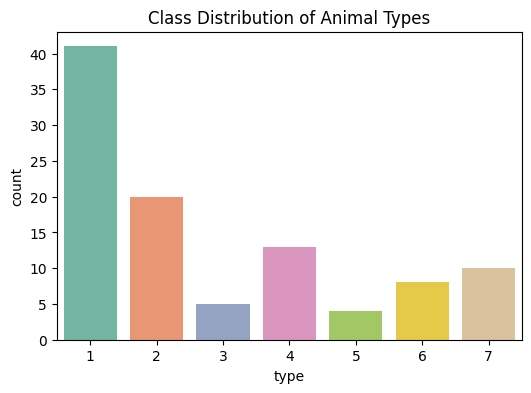

In [7]:
## Target distribution
plt.figure(figsize=(6,4))
sns.countplot(x="type", data=df, hue="type", palette="Set2", legend=False)
plt.title("Class Distribution of Animal Types")
plt.show()

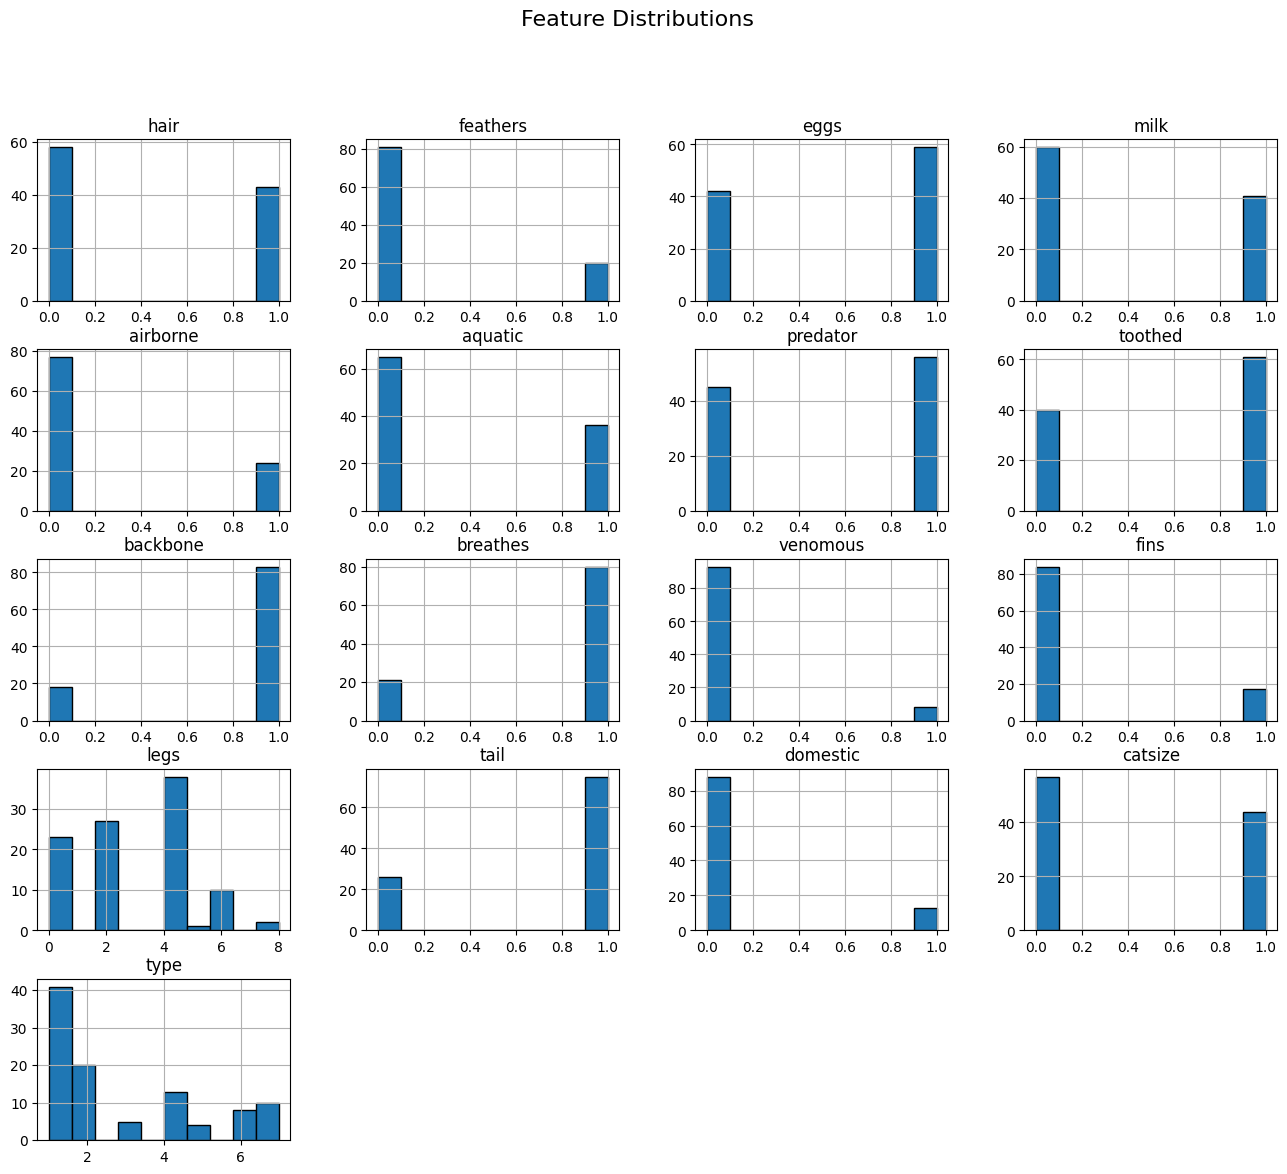

In [8]:
# Histograms for numerical features
df.drop(columns=["animal name"]).hist(figsize=(16,13), bins=10, edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

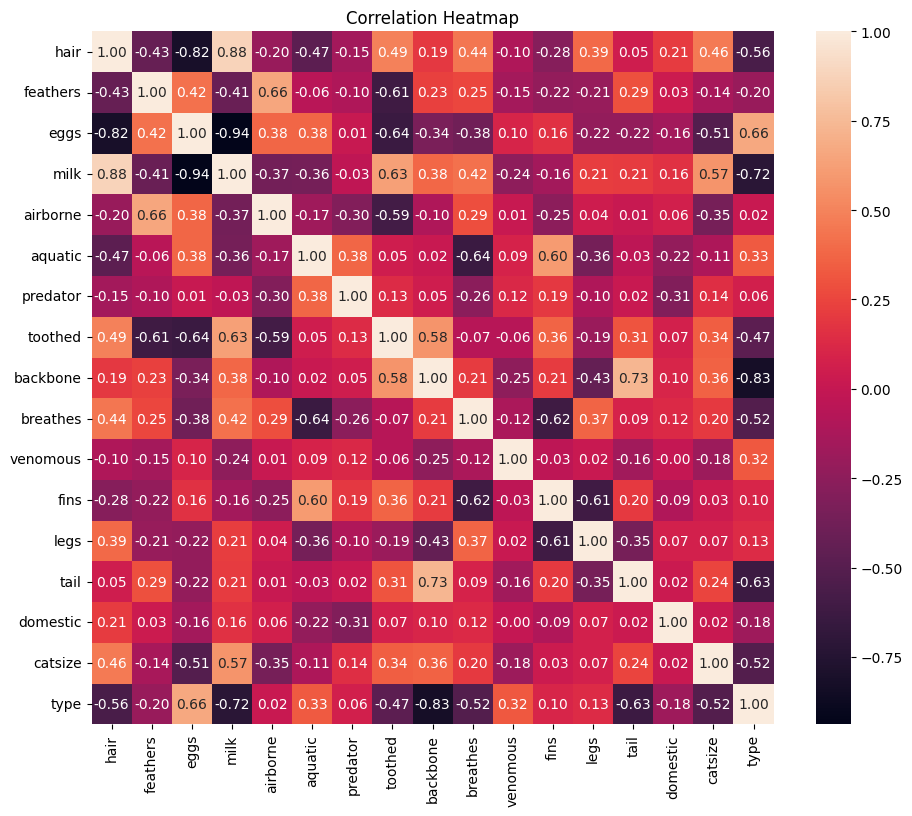

In [11]:
# Correlation heatmap
plt.figure(figsize=(11,9))
sns.heatmap(df.drop(columns=["animal name"]).corr(), annot=True,fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

- The correlation heatmap shows strong relationships between certain features, such as milk and eggs (strong negative correlation), and backbone with type.
- Some features exhibit moderate to high correlation, but none are redundant enough to require removal.

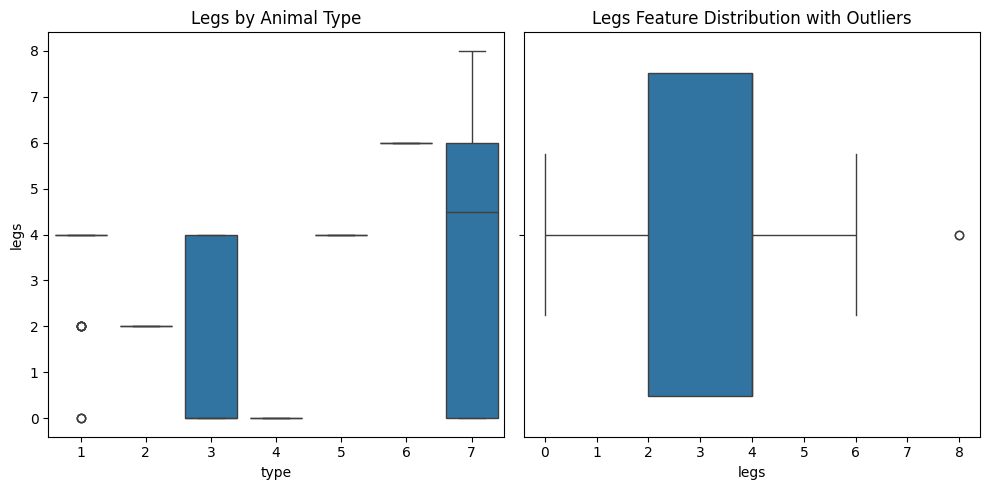

In [12]:
# Boxplot for legs (to check outliers)
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x="type", y="legs", data=df)
plt.title("Legs by Animal Type")
plt.subplot(1, 2, 2)
sns.boxplot(x=df['legs'])
plt.title("Legs Feature Distribution with Outliers")
plt.tight_layout()
plt.show()

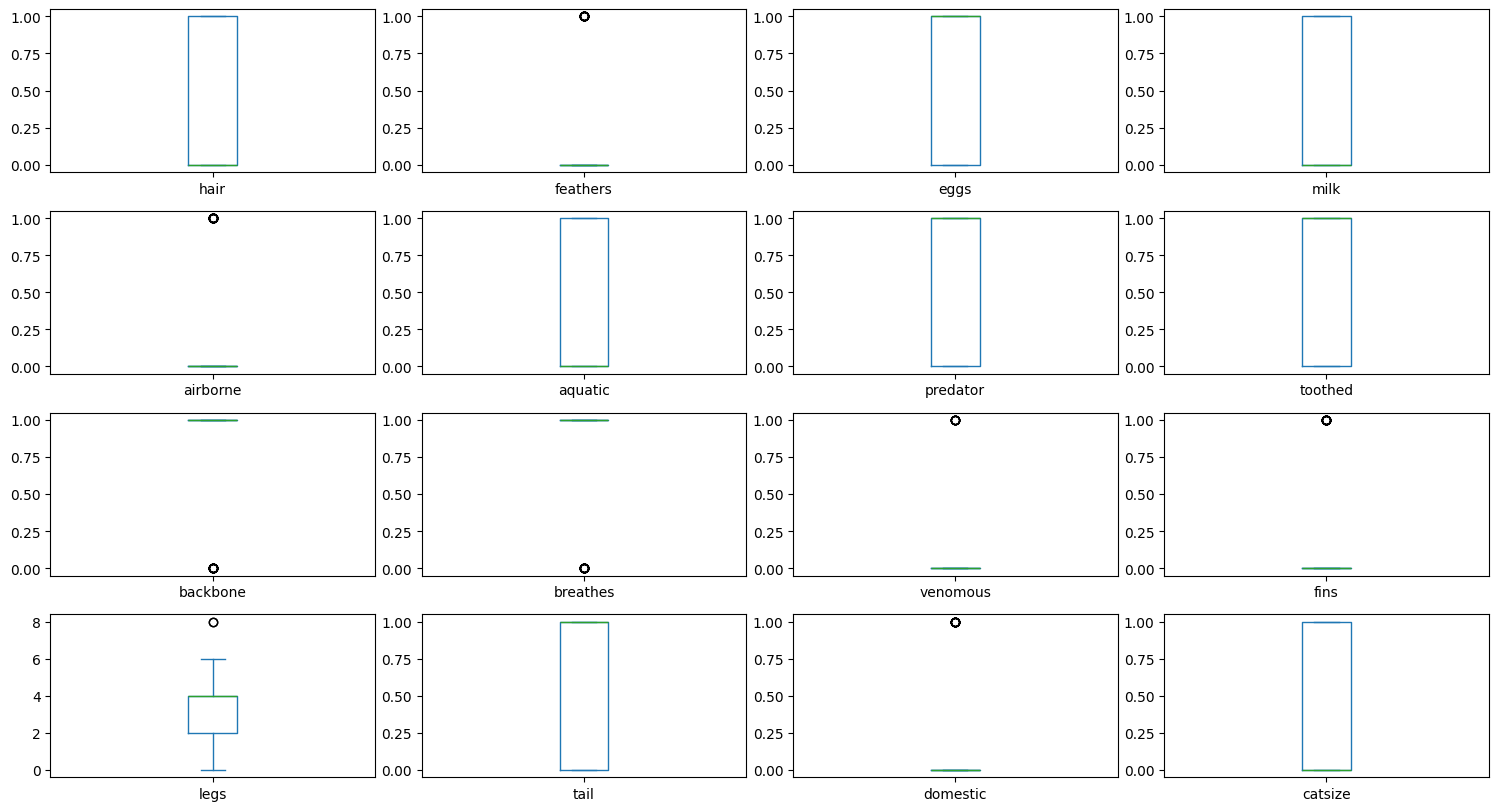

In [13]:
# Outlier Detection with Boxplots
df.drop(columns=["type"]).plot(kind="box", subplots=True, layout=(5,4), figsize=(15,10), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

- Boxplot visualization of all features shows no significant abnormal outliers.
- Most variables are binary (0/1), and any extreme values represent valid biological characteristics.
- Therefore, no outlier treatment was required.

In [14]:
# Drop unnecessary column
X = df.drop(columns=["animal name", "type"])
y = df["type"]

# Scale features (important for KNN)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

- The column animal name was removed as it does not contribute to classification.
- Features and target variable were separated, and StandardScaler was applied to normalize the data.
-  Scaling is necessary for KNN since it is a distance-based algorithm.

In [15]:
# Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (80, 16)
X_test shape: (21, 16)
y_train shape: (80,)
y_test shape: (21,)


In [17]:
# Initial KNN model with K=5
knn = KNeighborsClassifier(n_neighbors=5, metric="euclidean")
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



- The initial KNN model with K=5 achieved 100% accuracy on the test set, correctly classifying all animal types.
- Precision, recall, and F1-score for all classes were 1.00, indicating perfect model performance on this dataset.

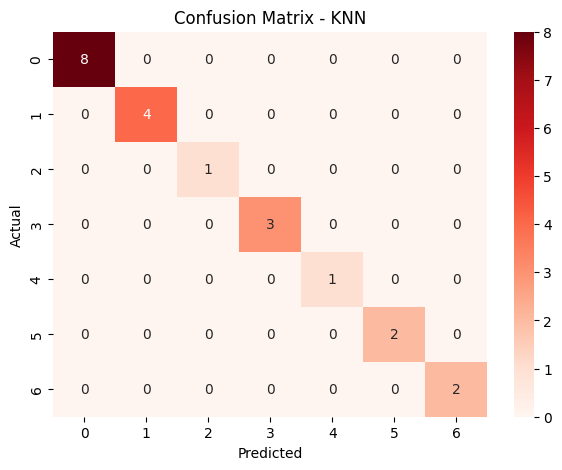

In [21]:
# Confusion Matrix
plt.figure(figsize=(7,5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Reds")
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

- The confusion matrix shows perfect classification, with all predictions lying on the diagonal and no misclassifications.
- This confirms that the KNN model achieved 100% accuracy on the test dataset.

In [20]:
from sklearn.model_selection import GridSearchCV

# Grid search for best K and metric
param_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "metric": ["euclidean", "manhattan", "minkowski"]
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring="accuracy")
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

C:\Users\Bibhuprasad Das\anaconda3\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'metric': 'euclidean', 'n_neighbors': 3}


GridSearchCV identified K = 3 with Euclidean distance as the optimal hyperparameters for the KNN model. 

In [22]:
# Best model
best_knn = grid.best_estimator_
y_pred_best = best_knn.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nTuned Report:\n", classification_report(y_test, y_pred_best))


Tuned Accuracy: 1.0

Tuned Report:
               precision    recall  f1-score   support

           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         2

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



- The tuned KNN model with K=3 and Euclidean distance achieved 100% accuracy on the test dataset.
-  All classes obtained precision, recall, and F1-score of 1.00, indicating perfect classification. 

In [23]:
# Apply PCA only on training data
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

# Train KNN with best parameters on PCA data
knn_pca = KNeighborsClassifier(
    n_neighbors=grid.best_params_['n_neighbors'],
    metric=grid.best_params_['metric']
)

knn_pca.fit(X_train_pca, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


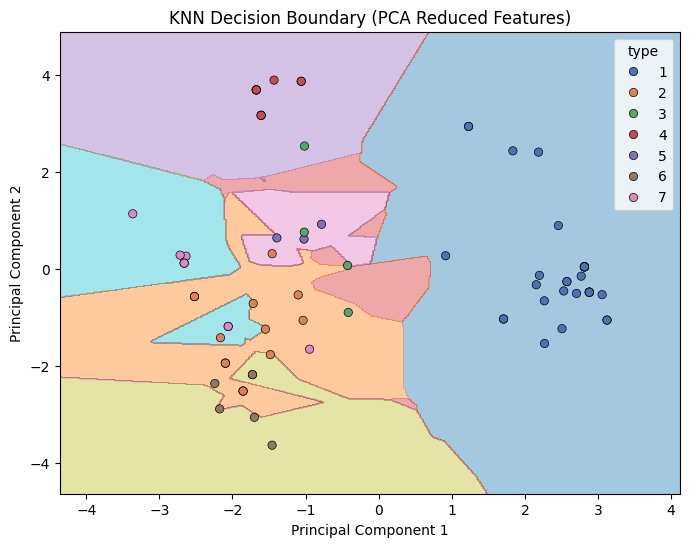

In [29]:
h = 0.02

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap="tab10")

sns.scatterplot(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    hue=y_train,
    palette="deep",
    edgecolor="k"
)

plt.title("KNN Decision Boundary (PCA Reduced Features)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

- The PCA-based decision boundary visualization shows clear separation between animal classes in two-dimensional space.
- Most classes form distinct clusters with minimal overlap, enabling accurate classification.


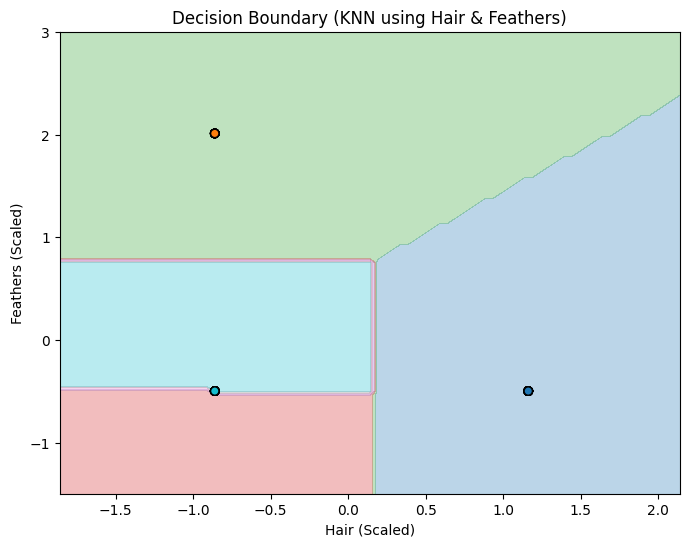

In [31]:
# Select two specific features for visualization
X_vis = df[["hair", "feathers"]]
y_vis = df["type"]

# Scale only these two features
scaler_vis = StandardScaler()
X_vis_scaled = scaler_vis.fit_transform(X_vis)

# Train-test split
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis_scaled, y_vis, test_size=0.2, random_state=42, stratify=y_vis
)

# Train KNN using best parameters
knn_vis = KNeighborsClassifier(
    n_neighbors=grid.best_params_['n_neighbors'],
    metric=grid.best_params_['metric']
)

knn_vis.fit(X_train_vis, y_train_vis)

# Create mesh grid
x_min, x_max = X_vis_scaled[:, 0].min() - 1, X_vis_scaled[:, 0].max() + 1
y_min, y_max = X_vis_scaled[:, 1].min() - 1, X_vis_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),np.arange(y_min, y_max, 0.05))

# Predict
Z = knn_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot
plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="tab10")

plt.scatter(X_vis_scaled[:, 0],X_vis_scaled[:, 1],c=y_vis,cmap="tab10",edgecolor="k")

plt.xlabel("Hair (Scaled)")
plt.ylabel("Feathers (Scaled)")
plt.title("Decision Boundary (KNN using Hair & Feathers)")
plt.show()

- When only Hair and Feathers features were used, the decision boundary showed significant overlap between classes.
- This indicates that two features are insufficient for complete class separation.

### Conclusion

1. In this study, the K-Nearest Neighbors (KNN) algorithm was applied to classify animal types using the Zoo dataset.
2. After preprocessing, scaling, and stratified train-test splitting, the model achieved 100% accuracy on the test set.
3. Hyperparameter tuning using GridSearchCV confirmed that K=3 with Euclidean distance was optimal.
4. PCA-based decision boundary visualization showed clear class separation, supporting the model’s perfect performance.
5. Overall, the results demonstrate that KNN is highly effective for this well-structured and separable dataset.

#### Interview Questions

##### 1. What are the key hyperparameters in KNN?

1. n_neighbors (K)

- Number of nearest neighbors used for classification.
- Small K → more sensitive to noise.
- Large K → smoother decision boundary.

2. metric (Distance Metric)

- Determines how distance between points is calculated.
- Common choices: Euclidean, Manhattan, Minkowski.
- Affects how similarity is measured.

3. weights

- "uniform" → all neighbors have equal influence.
- "distance" → closer neighbors have more influence.

4. p (for Minkowski metric)

- p=1 → Manhattan distance
- p=2 → Euclidean distance



##### 2. What distance metrics can be used in KNN?

1. Euclidean Distance

- Most common metric
- Straight-line distance between two points
- Best for continuous, scaled data

2. Manhattan Distance

- Sum of absolute differences
- Works well when features represent grid-like movement
  
3. Minkowski Distance

- General form of Euclidean and Manhattan
- Controlled by parameter p
- p=1 → Manhattan, p=2 → Euclidean

4. Hamming Distance

- Used for categorical or binary features
- Counts number of differing attributes